**Citywide Payroll Data (Fiscal Year)**

INCTOT (Total Personal Income): Dependent Variable ($Y$)

AGE (Age): main Independent Variable ($X$).

EDUC (Education):

  073: High School Diploma

  081: Some College (but no degree)

  111: Bachelor's Degree

  123: Master's Degree

  125: Professional/Doctorate Degree

  Values below 73 are people who didn't finish high school.

STATEFIP (36): code for New York.

YEAR: years 2020-2024


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/Econometrics/income.csv'  #data from years 2020-2024
df = pd.read_csv(path)
df.head()

,YEAR,SERIAL,MONTH,CPSID,ASECFLAG,ASECWTH,STATEFIP,PERNUM,CPSIDP,CPSIDV,ASECWT,AGE,EDUC,INCTOT
0,2020,6966,3,20181204552400,1,3461.4784,36,1,20181204552401,201812045524012,3461.4784,76,123,9238
1,2020,6966,3,20181204552400,1,3461.4784,36,2,20181204552402,201812045524022,3461.4784,80,125,24290
2,2020,6968,3,20181204547700,1,1897.8778,36,1,20181204547701,201812045477011,1897.8778,60,92,2508
3,2020,6968,3,20181204547700,1,1897.8778,36,2,20181204547702,201812045477021,1897.8778,60,73,71667
4,2020,6969,3,20190104556300,1,3387.2188,36,1,20190104556301,201901045563011,3387.2188,85,123,74850


In [ ]:
import numpy as np

# "Missing/N/A" Income (The 999999999 values)
df_clean = df[df['INCTOT'] < 9999999].copy()
df_clean = df_clean[df_clean['INCTOT'] > 0]

df_clean = df_clean[(df_clean['AGE'] >= 18) & (df_clean['AGE'] <= 65)]

df_clean['log_income'] = np.log(df_clean['INCTOT'])

edu_map = {
    1: 0, 10: 4, 20: 6, 30: 8, 40: 9, 50: 10, 60: 11,
    71: 12, 73: 12, 81: 14, 91: 14, 92: 14,
    111: 16, 123: 18, 124: 20, 125: 20
}

df_clean['years_schooling'] = df_clean['EDUC'].map(edu_map)

# Formula: Age - Schooling - 6 = potential working exp
df_clean['experience'] = df_clean['AGE'] - df_clean['years_schooling'] - 6

df_clean = df_clean[df_clean['experience'] >= 0]

df_clean['has_college'] = (df_clean['EDUC'] >= 111).astype(int)

print(f"Rows remaining: {len(df_clean)}")
df_clean[['AGE', 'INCTOT', 'log_income', 'experience', 'has_college']].head()

Rows remaining: 15327


,AGE,INCTOT,log_income,experience,has_college
2,60,2508,7.827241,40.0,0
3,60,71667,11.179786,42.0,0
8,19,15468,9.646529,2.0,0
9,27,138400,11.837903,5.0,1
10,57,9797,9.189831,39.0,0


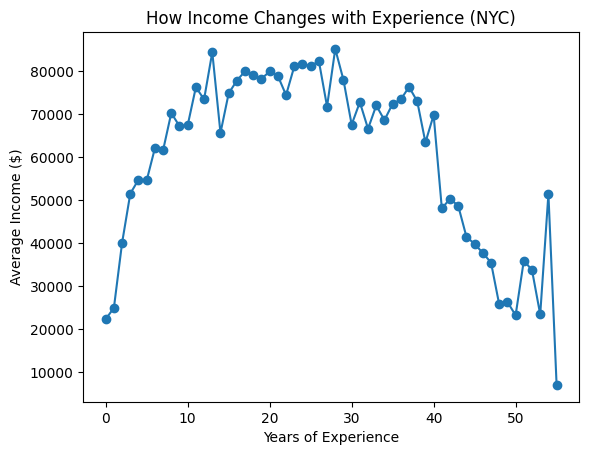

In [ ]:
import matplotlib.pyplot as plt
avg_income = df_clean.groupby('experience')['INCTOT'].mean()

plt.plot(avg_income.index, avg_income.values, marker='o')
plt.xlabel('Years of Experience')
plt.ylabel('Average Income ($)')
plt.title('How Income Changes with Experience (NYC)')
plt.show()

In [ ]:
df_clean['experience_sq'] = df_clean['experience'] ** 2

df_clean[['AGE', 'INCTOT', 'log_income', 'experience', 'experience_sq', 'has_college']].head()

,AGE,INCTOT,log_income,experience,experience_sq,has_college
2,60,2508,7.827241,40.0,1600.0,0
3,60,71667,11.179786,42.0,1764.0,0
8,19,15468,9.646529,2.0,4.0,0
9,27,138400,11.837903,5.0,25.0,1
10,57,9797,9.189831,39.0,1521.0,0


In [ ]:
print(df_clean.shape)

(15327, 20)


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def get_edu_level(code):
    if code >= 125: return 'Doctorate'
    if code >= 123: return 'Masters'
    if code >= 111: return 'Bachelors'
    if code >= 81:  return 'SomeCollege'
    if code >= 73:  return 'HS_Diploma'
    return 'Less_than_HS'

df_clean['edu_level'] = df_clean['EDUC'].apply(get_edu_level)

formula = 'log_income ~ experience + experience_sq + years_schooling + C(YEAR) + C(edu_level)'
model = smf.ols(formula=formula, data=df_clean).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     127.4
Date:                Tue, 12 May 2026   Prob (F-statistic):          5.84e-305
Time:                        00:22:32   Log-Likelihood:                -31025.
No. Observations:               15327   AIC:                         6.208e+04
Df Residuals:                   15314   BIC:                         6.218e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       